
image 1/1 /tf/ipynb/../ramp-data/sample_2/yolo_v11/images/train/OAM-619224-523266-20.jpg: 256x256 13 rooftops, 6.9ms
Speed: 0.7ms preprocess, 6.9ms inference, 87.5ms postprocess per image at shape (1, 3, 256, 256)
/tf/sam_vit_b_01ec64.pth
https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
vit_b


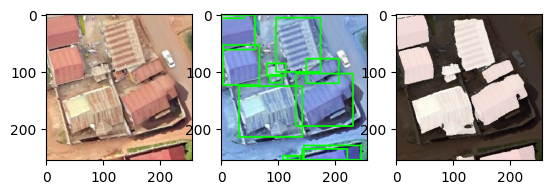

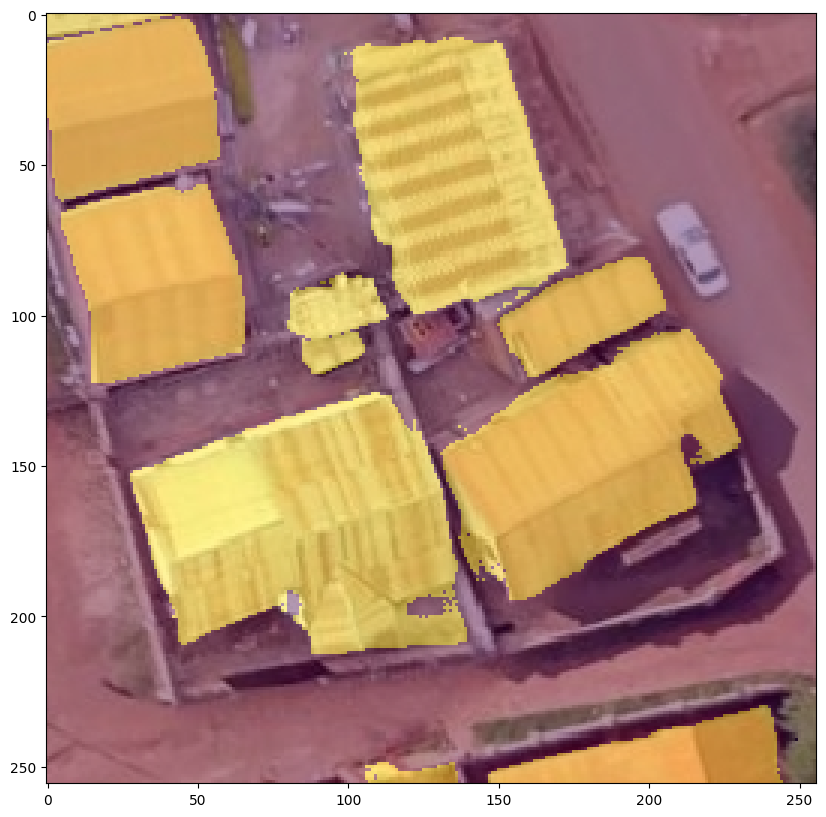

[array([[108, 253],
       [109, 252],
       [110, 253],
       [110, 254],
       [109, 255],
       [108, 254]]), array([[110, 249],
       [109, 250],
       [106, 250],
       [107, 250],
       [108, 251],
       [107, 252],
       [106, 252],
       [106, 254],
       [107, 255],
       [136, 255],
       [136, 252],
       [135, 251],
       [135, 249],
       [134, 249],
       [133, 250],
       [130, 250],
       [129, 251],
       [125, 251],
       [124, 252],
       [117, 252],
       [115, 250],
       [114, 250],
       [113, 249]]), array([[237, 230],
       [236, 231],
       [234, 231],
       [233, 232],
       [230, 232],
       [229, 233],
       [225, 233],
       [224, 234],
       [222, 234],
       [221, 235],
       [218, 235],
       [217, 236],
       [216, 236],
       [215, 237],
       [208, 237],
       [207, 238],
       [203, 238],
       [202, 239],
       [201, 239],
       [199, 241],
       [195, 241],
       [194, 242],
       [188, 242],
       

In [1]:
# Standard library imports
import os
import time
import warnings
import ultralytics
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from segment_anything import SamAutomaticMaskGenerator
import supervision as sv
import torch
from segment_anything import sam_model_registry
from segment_anything import SamPredictor
import numpy as np
import urllib.request
from imantics import Mask



# load the YOLOv8 model
model = YOLO(f"{os.getcwd()}/../yolo11n-seg.pt")

IMAGE_PATH = f"../ramp-data/sample_2/yolo_v11/images/train/OAM-619224-523266-20.jpg"
# run the model on the image
results = model.predict(source=IMAGE_PATH, conf=0.25)
predicted_boxes = results[0].boxes.xyxy


CHECKPOINT_PATH= os.environ["SAM_CHECKPOINT_PATH"] #"../sam_vit_b_01ec64.pth"

print (os.environ["SAM_CHECKPOINT_PATH"] )
print (os.environ["SAM_CHECKPOINT_URL"] )
print (os.environ["SAM_MODEL_TYPE"] )

if not os.path.exists(CHECKPOINT_PATH):
    urllib.request.urlretrieve(os.environ["SAM_CHECKPOINT_URL"] , CHECKPOINT_PATH)

MODEL_TYPE = os.environ["SAM_MODEL_TYPE"]#"vit_b"
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device=DEVICE)


# read in the image for visualization
image = cv2.imread(IMAGE_PATH, cv2.IMREAD_COLOR)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# mask_generator = SamAutomaticMaskGenerator(sam)

# result = mask_generator.generate(image_rgb)

# mask_annotator = sv.MaskAnnotator(color_map = "index")
# detections = sv.Detections.from_sam(result)
# annotated_image = mask_annotator.annotate(image, detections)

# plt.imshow(annotated_image)
# plt.axis('off') # Optional: remove axes
# plt.title('YOLOv11 predictions') # Optional: add a title
# plt.show()




mask_predictor = SamPredictor(sam)
mask_predictor.set_image(image_rgb)


transformed_boxes = mask_predictor.transform.apply_boxes_torch(
    results[0].boxes.xyxy, image.shape[:2])

mask_predictor.set_image(image)

masks, scores, logits = mask_predictor.predict_torch(
    boxes=transformed_boxes,
    multimask_output=False,
    point_coords=None,
    point_labels=None,
)
masks = np.array(masks.cpu())


# use cv2 to visualize the bounding boxes on the image
for box in predicted_boxes:
#  sam_box = np.array([ int(box[0]), int(box[1]), int(box[2]), int(box[3]) ])   
 cv2.rectangle(image, (int(box[0]), int(box[1])), (int(box[2]), int(box[3])), (0, 255, 0), 2)
#  masks, scores, logits = mask_predictor.predict(
#     box=sam_box,
#     multimask_output=True
#  )
 #print(box)

# Display the image using Matplotlib
# plt.imshow(image)
# plt.axis('off') # Optional: remove axes
# plt.title('YOLOv11 predictions') # Optional: add a title
# plt.show()

# combine all masks into one for easy visualization
final_mask = None
for i in range(len(masks) - 1):
  if final_mask is None:
    final_mask = np.bitwise_or(masks[i][0], masks[i+1][0])
  else:
    final_mask = np.bitwise_or(final_mask, masks[i+1][0])

#plt.figure(figsize=(10, 10))
f, axes = plt.subplots(1, 3)
axes[0].imshow(image_rgb)
axes[1].imshow(image)

#axes[2].figure(figsize=(10, 10))
#plt.figure(figsize=(10, 10))
axes[2].imshow(image_rgb)
#plt.imshow(image)
axes[2].imshow(final_mask, cmap='gray', alpha=0.7)

#plt.tight_layout()
plt.show()

# visualize the predicted masks
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)
#plt.imshow(image)
plt.imshow(final_mask, cmap='viridis', alpha=0.4)
plt.show()

polygons = Mask(final_mask).polygons()
points = polygons.points
print(points)
